# Modification and Aggregation

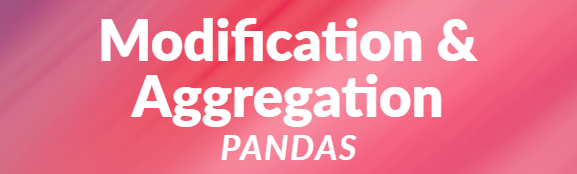

<div class="alert alert-warning">     
<b> Table of Contents </b>

1. [Introduction](#introduction)
2. [Add columns](#addcolumns)
3. [Add rows](#assrows)
4. [Remove columns and rows](#remove)
5. [Modify values based on Condition](#modify)
6. [Concatenation and Union](#concatenation)
7. [Grouping and Aggregating](#grouping)
8. [Advanced Aggregations](#advanced)
9. [Exercise](#exercise)

<div class="alert alert-warning">
    <b> I. <i>Introduction</i></b>
    <a id="introduction"></a></div>

In [232]:
import pandas as pd
import numpy as np

In [233]:
df2 = pd.DataFrame([
    ('Foreign Cinema', 'Restaurant', 289.0),
    ('Liho Liho', 'Restaurant', 224.0),
    ('500 Club', 'bar', 80.5),
    ('The Square', 'bar', 25.30)
], columns=('name', 'type', 'AvgBill'))

df2

,name,type,AvgBill
0,Foreign Cinema,Restaurant,289.0
1,Liho Liho,Restaurant,224.0
2,500 Club,bar,80.5
3,The Square,bar,25.3


<div class="alert alert-warning">
    <b> II. <i>Add columns</i></b>
    <a id="addcolumns"></a></div>

We have several ways to add columns to a dataFrame:

- __Direct assignment__: By the name of the column we want to add, just as we add a new key to a dictionary.
- __insert__: is a method that requires 3 parameters: 
    - the position where we want to add the column (loc).
    - its name (column).
    - the list of values (value).
- __assign__: very similar to the previous one, but it allows adding multiple columns.

__Direct Assignment__: It is like a dictionary. We can add a single value to the new Series:

In [234]:
df2['Day'] = "Monday"
df2

,name,type,AvgBill,Day
0,Foreign Cinema,Restaurant,289.0,Monday
1,Liho Liho,Restaurant,224.0,Monday
2,500 Club,bar,80.5,Monday
3,The Square,bar,25.3,Monday


Or multiple values:

In [235]:
df2['Day'] = ['Monday', 'Tuesday', 'Wednesday', 'Thursday']
df2

,name,type,AvgBill,Day
0,Foreign Cinema,Restaurant,289.0,Monday
1,Liho Liho,Restaurant,224.0,Tuesday
2,500 Club,bar,80.5,Wednesday
3,The Square,bar,25.3,Thursday


``insert``: We indicate the first position, the column name and the values we want to add:

In [236]:
df2.insert(loc=1, column="Stars", value=[2,2,3,4])
df2

,name,Stars,type,AvgBill,Day
0,Foreign Cinema,2,Restaurant,289.0,Monday
1,Liho Liho,2,Restaurant,224.0,Tuesday
2,500 Club,3,bar,80.5,Wednesday
3,The Square,4,bar,25.3,Thursday


``assign``: Add multiple columns in a single operation. We can see that the column named ``AvgHalfBill`` is the result of dividing a column by 2.

In [237]:
df3 = df2.assign(
    AvgHalfBill = df2.AvgBill / 2,
    Michelin_Star = 3
)
df3

,name,Stars,type,AvgBill,Day,AvgHalfBill,Michelin_Star
0,Foreign Cinema,2,Restaurant,289.0,Monday,144.50,3
1,Liho Liho,2,Restaurant,224.0,Tuesday,112.00,3
2,500 Club,3,bar,80.5,Wednesday,40.25,3
3,The Square,4,bar,25.3,Thursday,12.65,3


We can also create a new column from existing data: 

In [238]:
df2["AvgBillIVA"] = df2["AvgBill"] * 1.21
df2

,name,Stars,type,AvgBill,Day,AvgBillIVA
0,Foreign Cinema,2,Restaurant,289.0,Monday,349.690
1,Liho Liho,2,Restaurant,224.0,Tuesday,271.040
2,500 Club,3,bar,80.5,Wednesday,97.405
3,The Square,4,bar,25.3,Thursday,30.613


<div class="alert alert-warning">
    <b> III. <i>Add rows</i></b>
    <a id="addrows"></a></div>

To add rows (a new sample) to a dataframe, we have the ``concat`` method, which concatenates two or more dataframes separated by commas. We will create a copy of the previous dataframe and assign it to a new dataframe with ``copy``.

In [239]:
df_rows = df2.copy() 

rows = {"name":"Isaacs", "type":"bar" ,"AvgBill":[148.2], "day":"Friday"}

nou_df = pd.concat([df_rows, pd.DataFrame(rows)])

In [240]:
nou_df

,name,Stars,type,AvgBill,Day,AvgBillIVA,day
0,Foreign Cinema,2.0,Restaurant,289.0,Monday,349.690,NaN
1,Liho Liho,2.0,Restaurant,224.0,Tuesday,271.040,NaN
2,500 Club,3.0,bar,80.5,Wednesday,97.405,NaN
3,The Square,4.0,bar,25.3,Thursday,30.613,NaN
0,Isaacs,NaN,bar,148.2,NaN,NaN,Friday


<div class="alert alert-warning">
    <b> IV. <i>Remove columns and rows</i></b>
    <a id="remove"></a></div>

The ``drop`` method provides a new dataFrame without the row(s) or column(s) we select. If we want to remove columns, we can do so by specifying the list of columns in the ``columns`` parameter as follows:

In [241]:
df3.drop(columns=["Michelin_Star"], inplace=True)
df3

,name,Stars,type,AvgBill,Day,AvgHalfBill
0,Foreign Cinema,2,Restaurant,289.0,Monday,144.50
1,Liho Liho,2,Restaurant,224.0,Tuesday,112.00
2,500 Club,3,bar,80.5,Wednesday,40.25
3,The Square,4,bar,25.3,Thursday,12.65


``inplace=True``: modify the original DataFrame directly instead of returning a new one.

To delete rows, we use the same drop function, this time without the parameter we used previously; we simply specify the indices to delete:

In [242]:
df3.drop([1,3])

,name,Stars,type,AvgBill,Day,AvgHalfBill
0,Foreign Cinema,2,Restaurant,289.0,Monday,144.50
2,500 Club,3,bar,80.5,Wednesday,40.25


We can also remove rows based on a criterion:

In [243]:
df3.drop(df3[df3.AvgBill > 100].index)

,name,Stars,type,AvgBill,Day,AvgHalfBill
2,500 Club,3,bar,80.5,Wednesday,40.25
3,The Square,4,bar,25.3,Thursday,12.65


<div class="alert alert-warning">
    <b> V. <i>Modify values based on Condition</i></b>
    <a id="modify"></a></div>

In [244]:
df3.head()

,name,Stars,type,AvgBill,Day,AvgHalfBill
0,Foreign Cinema,2,Restaurant,289.0,Monday,144.50
1,Liho Liho,2,Restaurant,224.0,Tuesday,112.00
2,500 Club,3,bar,80.5,Wednesday,40.25
3,The Square,4,bar,25.3,Thursday,12.65


In [245]:
df3.loc[df3["name"] == "The Square", "Stars"] = 3
df3

,name,Stars,type,AvgBill,Day,AvgHalfBill
0,Foreign Cinema,2,Restaurant,289.0,Monday,144.50
1,Liho Liho,2,Restaurant,224.0,Tuesday,112.00
2,500 Club,3,bar,80.5,Wednesday,40.25
3,The Square,3,bar,25.3,Thursday,12.65


<div class="alert alert-warning">
    <b> VI. <i>Concatenation and Union</i></b>
    <a id="concatenation"></a></div>

Sometimes the data we have come in different files and need to be combined into a single file; this process involves concatenating dataframes. At other times, the data are complementary, meaning there are new columns in one dataframe, and this is known as performing join operations.

__Concatenation__

In [246]:
df1 = pd.DataFrame([
    ('A', 10),
    ('B', 20)
], columns=('name', 'value'))

df2 = pd.DataFrame([
    ('C', 30),
    ('D', 40)
], columns=('name', 'value'))

df_all = pd.concat([df1, df2])
df_all

,name,value
0,A,10
1,B,20
0,C,30
1,D,40


<div class="alert alert-info">

__Mini Exercise__
1. Why the index appear like that?. 

__Union__ 

Sometimes, there are dataframes that have complementary data.

In [247]:
df1 = pd.DataFrame([('Jhon', 1, "Italy"),
                   ('Pep', 2, "Germany"),
                   ('William', 3, "Finland"),
                   ('Snake', 4, "Italy")],
           columns=('name', 'ID', 'Country')
                 )
df1

,name,ID,Country
0,Jhon,1,Italy
1,Pep,2,Germany
2,William,3,Finland
3,Snake,4,Italy


In [248]:
df2 = pd.DataFrame([(1, 145.0, 3000.1),
                   ( 2, 189.2, 2030.2),
                   ( 3, 129.0, 3000.0),
                   ( 4, 198.1, 4020.2)],
           columns=('DNI', 'Weight', 'Salary')
                 )
df2

,DNI,Weight,Salary
0,1,145.0,3000.1
1,2,189.2,2030.2
2,3,129.0,3000.0
3,4,198.1,4020.2


``merge``: combines two DataFrames based on a common column.

In [249]:
df1.merge(df2, left_on='ID', right_on='DNI')

,name,ID,Country,DNI,Weight,Salary
0,Jhon,1,Italy,1,145.0,3000.1
1,Pep,2,Germany,2,189.2,2030.2
2,William,3,Finland,3,129.0,3000.0
3,Snake,4,Italy,4,198.1,4020.2


In case, both dataframes have the same column called ``'ID'``, we can use the parameter ``on = 'ID'``, which tells pandas to match rows where ID is the same in both tables.

In [250]:
df2 = pd.DataFrame([(1, 145.0, 3000.1), #No 2
                   ( 3, 129.0, 3000.0), # Multiples 3
                   ( 3, 159.0, 4000.0),
                   ( 3, 109.0, 5000.0),
                   ( 4, 198.1, 4020.2),
                   ( 5, 200.0, 5000.2)], #a new one 
           columns=('ID', 'Weight', 'Salary')
                 )
df2

,ID,Weight,Salary
0,1,145.0,3000.1
1,3,129.0,3000.0
2,3,159.0,4000.0
3,3,109.0,5000.0
4,4,198.1,4020.2
5,5,200.0,5000.2


<div class="alert alert-info">

__Mini Exercise__
1. Uncomment each line to see what it does. 

In [251]:
#df1.merge(df2, on='ID', how='inner')
#df1.merge(df2, on='ID', how='left')
#df1.merge(df2, on='ID', how='right')
#df1.merge(df2, how='cross')

- ``INNER JOIN``: Only keep rows where the ID exists in both DataFrames.
- ``LEFT JOIN``: Keep all rows from df1, Fill missing matches with NaN.
- ``RIGHT JOIN``: Keep all rows from df2.
- ``CROSS JOIN``: All combinations (Cartesian product)

<div class="alert alert-warning">
    <b> VII. <i>Grouping data and Aggregation</i></b>
    <a id="grouping"></a></div>

Grouping is a necessary operation for analysing data as it allows for:

- Applying statistical functions (such as sums, averages, counts, minims, maximums, etc.) to specific groups of data, making it easier to generate more manageable summaries
- Allows you to compare metrics or statistics from different groups within a dataset, such as seeing a variable's behaviour across different categories.
- It reduces data complexity by dividing it into smaller groups, allowing you to view the information more clearly and organisedly.

In [252]:
df= pd.read_csv("experiment.csv")
print(df)

   Nombre Apellidos  Altura Sexo  Nacimiento   Cof Categoria
0    Will     Smith    1.43    M  10/10/1920  0.19   laboral
1     Jon      Snow    1.98    M   10/1/1970  0.98   laboral
2    Laia   Ramirez    1.87    F  09/10/1987  0.76      cap6
3    Luzy      Raim    1.67    F  23/07/1979  0.56      cap6
4    Fein      Mang    1.78    M  12/03/1937  0.27      cap6
5  Victor     Colom    1.78    M  22/09/1957  0.97      cap8


In the following example, we group the data by the person’s gender using the `groupby` method, which returns a grouped DataFrame.
The ``groups`` attribute shows us the groups we have created:

In [253]:
grouped = df.groupby("Sexo")
grouped.groups

{'F': [2, 3], 'M': [0, 1, 4, 5]}

This attribute allows us to filter the data based on groups: 

In [254]:
dfM = df.loc[grouped.groups['M'].values] 
dfM

,Nombre,Apellidos,Altura,Sexo,Nacimiento,Cof,Categoria
0,Will,Smith,1.43,M,10/10/1920,0.19,laboral
1,Jon,Snow,1.98,M,10/1/1970,0.98,laboral
4,Fein,Mang,1.78,M,12/03/1937,0.27,cap6
5,Victor,Colom,1.78,M,22/09/1957,0.97,cap8


__Agregation__

The ``aggregate`` method allows us to create aggregation variables on the table obtained with ``groupby``. We specify the information we want to extract from each column using a dictionary. We specify the function to apply to the data in each group for each column to obtain a single value.

To illustrate this section, we will group the dataframe by ``Job`` Category. In this case, for the ``Height`` column, we will calculate the sum of the heights in the group, and for the ``Cof`` column, the mean.
We will specify the information we wish to obtain from each column using a dictionary. We specify the function we will apply to the data for each group in each column to obtain a single value.

In [255]:
dfg = df.groupby(["Categoria"]).aggregate({
    "Altura":"sum",
    "Cof":"mean"})

dfg

,Altura,Cof
Categoria,,
cap6,5.32,0.530
cap8,1.78,0.970
laboral,3.41,0.585


We can also aggregate multiple columns. It creates all the combinations of different columns that exist in the dataframe:

In [256]:

gr = df.groupby(['Sexo',"Categoria"]).mean(numeric_only=True)
gr

Altura    Cof
Sexo Categoria               
F    cap6        1.770  0.660
M    cap6        1.780  0.270
     cap8        1.780  0.970
     laboral     1.705  0.585

We can also count the number of elements each group has:

In [257]:
df.groupby("Sexo")["Categoria"].count()

Sexo
F    2
M    4
Name: Categoria, dtype: int64

In [258]:
gr = df.groupby(['Sexo',"Categoria"])["Sexo"].count()
print(gr)

Sexo  Categoria
F     cap6         2
M     cap6         1
      cap8         1
      laboral      2
Name: Sexo, dtype: int64


<div class="alert alert-warning">
    <b> VIII. <i>Advanced Aggregations</i></b>
    <a id="advanced"></a></div>

In [259]:
df = pd.read_csv("data_groups.csv")
print(df.head())

   Unnamed: 0        Dni                           Nom    CP      Ciutat Sexe  \
0           0  H61414629     María Dolores Arjona Jove  7800     Eivissa    M   
1           1  S3138381C                  Núria Quirós  7511     Ruberts    F   
2           2  J8698188C  Miguel José María Gil Vargas  7340       Alaro    M   
3           3  A48821615       Jordi Chaves Bustamante  7609  Bellavista    F   
4           4  U0247281I    Jana Rosa Collado Menéndez  7006       Palma    M   

  Tipus certificat cat  Punts  
0                    B     73  
1                    A     40  
2                    A     45  
3                    B     40  
4                    B     86  


We can group rows by city and postal code. Then, we select the certificate type. If we use ``aply`` we convert each group into a list of values. We put all values of each group into a Python list. This is useful for frequency analysis, histograms and customs aggregations.

In [260]:

dfc = df.groupby(["Ciutat","CP"])["Tipus certificat cat"].apply(list)
dfc

Ciutat      CP  
Alaro       7340    [A, C, B, A, A, B, A, D, A, B, A, B, B, A, B, ...
Ariany      7529    [B, A, B, A, A, B, A, B, A, B, A, A, C, A, B, ...
Bellavista  7609    [B, C, A, A, A, C, A, A, B, A, A, A, B, A, C, ...
Binissalem  7350    [A, B, B, C, C, A, A, A, C, A, C, A, B, B, D, ...
Eivissa     7800    [B, A, A, B, B, B, A, A, A, A, B, C, A, A, B, ...
La Savina   7870    [A, A, A, B, A, A, B, B, A, A, B, A, B, B, A, ...
Mao         7701    [B, C, B, C, B, C, A, B, B, B, A, C, C, A, C, ...
            7703    [B, A, B, C, A, A, B, A, C, B, A, B, C, A, B, ...
Palma       7006    [B, A, B, B, A, A, A, B, B, A, A, B, B, A, B, ...
            7009    [A, D, A, B, C, A, A, C, B, A, A, A, C, A, A, ...
            7013    [A, A, B, C, C, C, C, A, A, A, B, A, C, C, A, ...
Pedruscada  7590    [A, B, A, A, A, A, B, B, C, B, B, B, C, A, A, ...
Ruberts     7511    [A, A, A, B, C, A, B, A, A, B, B, A, C, B, B, ...
Name: Tipus certificat cat, dtype: object

In pandas, as well as using predefined aggregation functions such as sum(), mean(), min() or max(), we can also use our own (user-defined) functions to perform more flexible aggregations tailored to our needs.

These custom functions can be any Python function that takes a data series as input and returns a single value as the result. This allows us to apply specific calculations, advanced metrics or transformations that are not available natively in pandas.

In [261]:
f2 = df.groupby(["Ciutat","CP"]).agg({"Tipus certificat cat": np.size})
print(f2)

                 Tipus certificat cat
Ciutat     CP                        
Alaro      7340                   120
Ariany     7529                   113
Bellavista 7609                    98
Binissalem 7350                    93
Eivissa    7800                    91
La Savina  7870                    90
Mao        7701                    63
           7703                    45
Palma      7006                    36
           7009                    23
           7013                    37
Pedruscada 7590                   106
Ruberts    7511                    85


__Lamda functions__

In Python, lambda functions allow you to define small, anonymous functions in a compact way. They are particularly useful when you need a simple function for a one-off operation and don’t want to create a full function using `def`.

A lambda function is written on a single line and can take one or more arguments, but it can only contain a single expression, the result of which is returned automatically. Thanks to their simplicity, lambdas are very useful for operations such as filtering, transforming or sorting data, as well as when working with higher-order functions such as `map()`, `filter()` or `sorted()`.

Using them makes the code more expressive and concise in situations where defining a traditional function would be unnecessarily long. However, it is recommended to use them only for simple tasks, keeping code readability as a priority.

In [268]:

def count_above_20(series):
    return len([x for x in series if x > 20])

df.groupby("Sexe").agg({
    "Punts": [count_above_20, np.size]
})

Punts     
     count_above_20 size
Sexe                    
F               380  483
M               404  517

The DataFrame is split into groups based on the column "Sexe". For each group, looks at values in ``Punts`` column, keeps only values > 20 and counts them. 

A lambda function in Python is a small, anonymous function defined in a single line using the keyword lambda. It is often used when you need a simple function for a short period of time without formally defining it with def.

In [270]:
df.groupby("Tipus certificat cat").agg({
    "Punts": lambda x: x.mean()
})

,Punts
Tipus certificat cat,
A,50.115813
B,49.681034
C,48.045455
D,51.020408


<div class="alert alert-warning">
    <b> IX. <i>Exercise </i></b>
    <a id="exercise"></a>

<div class="alert alert-info">

__Mini Exercise__
1. Read data_groups.csv.
2. Add column 'Bonus'. If 'Punts'> 70, put 10 points, if not 0. 
3. Remove column 'Unnamed'.
4. Gruop by 'Ciutat' and compute the mean of points.
5. Create a group by 'Ciutat' and use agg() to compute the sum of points and the number of samples.